[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Feellived/tobigs-26th-stat-inference-regression/blob/main/assignment/assignment.ipynb)

# 투빅스 26기 1주차 2교시 — 통계적 추론 + 회귀 과제 · Framingham 심장연구

## 과제 목적

이번 과제는 **강의에서 다룬 Framingham 심장연구(참가자 4,240명)** 데이터를 직접 로드 → EDA → 추론 → 회귀 → 해석/예측까지 관통하는 프로젝트입니다. 강의가 개념을 '보여주는' 쪽이었다면, 과제는 같은 데이터로 그 개념을 '직접 만들어 보는' 쪽입니다.

Framingham 연구는 '위험인자(risk factor)' 개념을 만든 곳이고, 통계적 추론과 회귀는 곧 **그 위험인자를 발굴하는 절차**입니다 — **절차① 검정**(어떤 변수가 발병군에서 다른가)과 **절차② 회귀**(차이가 얼마나 큰가, 통제해도 남는가). 이 연구가 임상에 남긴 최종 산물은 **"10년 내 심장질환 발생 확률"을 개인별로 계산하는 Framingham Risk Score**였습니다. 강의는 `sysBP`(연속) 회귀에서 멈췄지만, **이 과제는 진짜 표적 `TenYearCHD`(0/1)를 로지스틱 회귀로 예측하는 데까지 완성**합니다.

주인공은 `sysBP`(수축기혈압, 연속)와 `TenYearCHD`(10년 내 관상동맥심질환, 0/1)입니다. 강의에서 본 숫자 — 평균 혈압의 신뢰구간, 심장병군 vs 비심장병군 혈압 차이 검정, 나이→혈압 회귀, 다중회귀와 공선성 — 을 **직접 재현·해석**하고, 마지막에 **로지스틱 회귀로 발병 위험을 예측(= Risk Score의 엔진)** 합니다. 결측·이진변수·다변수가 있어 까다롭지만, 그 까다로움이 실전 감각입니다.

각 코드 셀의 빈칸(`# TODO: ____`, `____`)을 채우며 "지금 어느 단계에서 무엇을 하는가"를 확인하세요. **맨 위 셀부터 순서대로** 실행하면 앞 단계 결과가 뒤로 이어집니다.

## 채점 · AI 활용 안내

- **실행은 기본점, 사고가 변별점입니다.** 값을 얻는 것만으로는 부족하고, 특히 §2 "스스로 생각하기"에서 본인 관찰값으로 '왜 그런가'를 설명해야 점수가 갈립니다.
- **답이 본인 시드·실행값에 묶여 있습니다.** `MY_SEED`가 사람마다 달라 부트스트랩 신뢰구간·CLT 시뮬레이션·train/test 분할 결과가 **학생마다 다릅니다.** AI의 일반적 숫자를 옮기면 **본인 실행값과 어긋나 감점**됩니다. 반드시 본인 노트북 값을 인용하세요.
- **AI(GPT 등)는 검산기·설명 도우미로만.** 판단·검증·해석은 본인이 합니다. §5에 실제 대화와 함께, AI가 준 답 중 틀렸거나 이 데이터엔 안 맞았던 것을 어떻게 잡아냈는지 정리하세요.


## 0. 환경 설정 — 라이브러리, 시드, 데이터 로드

이번 과제는 **Framingham 심장연구** 데이터를 씁니다. 미국 프레이밍햄 주민을 수십 년간 추적한 역학 코호트로, "심혈관 위험요인" 개념이 여기서 나왔습니다. 참가자 **4,240명**에 대해 성별·나이·흡연·혈압·콜레스테롤 등 16개 변수가 있고, 마지막 열 `TenYearCHD`가 **10년 안에 관상동맥심질환(CHD) 발생 여부(1/0)** 입니다. 주인공 변수는 **`sysBP`(수축기 혈압)** 입니다.

이 셀에서 하는 일은 세 가지입니다.

**1) 라이브러리 import.** 이후 모든 셀이 여기서 불러온 이름(`np`, `pd`, `smf` 등)을 씁니다. 한 번만 실행하면 됩니다.

**2) `MY_SEED` 설정.** *시드(seed)* 는 난수 생성기의 출발점으로, 같은 시드를 주면 **똑같은 난수**가 재현됩니다. CLT 시뮬레이션·부트스트랩·train/test 분할 등 무작위 단계가 나오므로, 시드를 고정해야 결과가 재현되고 채점이 가능합니다. **본인 학번 뒷 4자리**를 시드로 쓰세요(예: 2026-12345 → `2345`).

**3) 데이터 로드.** 공개 URL에서 먼저 읽고, 실패하면 같은 폴더의 `framingham.csv`로 대체합니다. `try/except`로 감싸 어느 환경에서도 멈추지 않게 합니다.

> 시드 고정은 "결과를 편향시킨다"는 뜻이 아니라 무작위 절차를 **재현 가능하게** 만들 뿐입니다. 시드를 바꾸면 숫자는 조금씩 달라지지만 결론(신뢰구간 폭, 검정 유의성 등)은 사실상 같아야 정상입니다.


In [13]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 라이브러리 import — 이후 모든 셀이 여기서 불러온 이름을 그대로 사용

# 그래프 기본 스타일(선택)
sns.set_theme(style="whitegrid")

# (2) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 9003              # TODO: 학번 뒷 4자리
np.random.seed(MY_SEED)        # TODO: MY_SEED로 난수 생성기 고정

# (3) 데이터 로드 — 공개 URL 우선, 실패 시 업로드한 로컬 파일로 대체
# 데이터 로드: 공개 URL에서 바로 읽습니다(업로드 불필요). 실패 시 업로드한 로컬 파일 사용.
DATA_URL = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/master/framingham.csv"
try:
    df = pd.read_csv(DATA_URL)
except Exception:
    df = pd.read_csv("framingham.csv")   # Colab: 좌측 파일 탭에 framingham.csv 업로드 후

# 이후 섹션 전체가 공유하는 수치형 열 목록
num_cols = ["age", "sysBP", "diaBP", "totChol", "BMI", "glucose", "heartRate"]

# 로드 확인
print("데이터 크기 (행, 열):", df.shape)          # 기대: (4240, 16)
print("MY_SEED =", MY_SEED)
print("\n[첫 3행]")
print(df.head(3))
print("\n[열별 결측치 개수 (0이 아닌 것만)]")
print(df.isna().sum()[df.isna().sum() > 0])       # TODO: 결측이 어느 열에 있는지 확인


데이터 크기 (행, 열): (4240, 16)
MY_SEED = 9003

[첫 3행]
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   

   TenYearCHD  
0           0  
1           0  
2           0  

[열별 결측치 개수 (0이 아닌 것만)]
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `df.shape`는 무엇인가요? 행(참가자) 수와 열(변수) 수를 **본인이 본 실제 숫자**로 적으세요.

    답: 행 수: 4240개, 열 수: 16개


2. **결측이 가장 많은 열**은 무엇이고 몇 개인가요? Framingham은 결측이 있어 뒤 섹션에서 `dropna()` 처리가 필요하니, 어떤 열이 문제일지 미리 봐 두세요.

    답: glucose, 388개


3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `df.shape`가 달라질까요? 왜 그런지 한 줄로 설명하세요.

    답: 아니요, MY_SEED는 난수 생성에만 영향을 주고 파일을 그대로 읽어온 뒤 df.shape를 실행하면 데이터 자체가 변하는 것은 아니기 때문에 달라지지 않습니다.

> 힌트(3번): 시드는 *무작위 절차*(시뮬레이션·표본추출)에만 영향을 줍니다. 파일에서 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.


## 1. 필수 과제 — 로드 → EDA → 추론 → 회귀 → 예측 (한 흐름)

아래 1.1~1.10을 순서대로 완성합니다. 앞 단계의 결과가 뒤 단계로 이어지므로 **위에서부터 차례로** 실행하세요.

### 1.1 데이터 만나기 — 구조와 결측

이번 데이터는 **Framingham 심장연구**(framingham.csv, $n=4{,}240$), 심혈관 위험요인 연구의 고전인 역학 코호트입니다. 강의에서 쓴 그 데이터를 그대로 씁니다.

**두 주인공:**
- **`TenYearCHD`** — **반응변수(예측 대상)**. 0/1 이진값으로 추적 10년 내 **관상동맥심질환(CHD)** 발생 여부. 1=발병, 0=무발병.
- **`sysBP`** — **주인공 연속변수**, 수축기 혈압(mmHg). 값이 클수록 대체로 위험이 큼. 뒤 섹션의 CLT·부트스트랩·t검정·회귀가 전부 이 `sysBP` 중심으로 돌아갑니다.

**결측(missing value)** 이 이번 데이터의 핵심 학습 포인트입니다. tips 데이터와 달리 실제 임상·역학 데이터는 값이 비어 있고, Framingham도 예를 들어 **혈당(`glucose`)은 388명분이 비어 있습니다.**

> **결측(NA/NaN)이란?** "0"이나 "없음"이 아니라 **애초에 관측되지 않아 알 수 없는** 상태. pandas는 `NaN`으로 표시하고, `df.isna().sum()`으로 열마다 개수를 셉니다.

결측을 어떻게 다루느냐에 따라 평균·신뢰구간·검정·회귀 결과가 달라집니다. 이 섹션은 "어디에 결측이 얼마나 있는지"를 먼저 확인하는 **정찰 단계**이고, 실제 처리(`dropna` 등)는 각 분석 섹션에서 필요한 열에만 합니다.


In [14]:
# 1) 데이터 크기: (행 개수, 열 개수)
print("shape (행, 열):", df.shape)        # TODO: df의 크기(행,열)를 출력

# 2) 앞부분 5행 미리보기 — 값이 어떻게 생겼는지 눈으로 확인
print("\n=== df.head() ===")
print(df.head())                            # TODO: 앞 5행 미리보기

# 3) 열별 자료형 + 비결측(non-null) 개수 한눈에 보기
print("\n=== df.info() ===")
df.info()                           # TODO: 열별 dtype/비결측 개수 요약

# 4) 열별 결측치 개수 (많은 순으로 정렬)
print("\n=== 결측치 개수 df.isna().sum() ===")
na_counts = df.isna().sum().sort_values(ascending=False)   # TODO: 열별 결측 개수 세기
print(na_counts)

# 5) 결측이 있는 열만 골라 개수 + 비율(%)로 정리
na_only = na_counts[na_counts > 0]
na_table = pd.DataFrame({
    "결측개수": na_only,
    "결측비율(%)": (na_only / len(df) * 100).round(2),
})
print("\n=== 결측이 있는 열 (개수 + 비율) ===")
print(na_table)

# 6) 반응변수 TenYearCHD(0/1) 분포 확인
print("\n=== 반응변수 TenYearCHD 분포 ===")
print(df["TenYearCHD"].value_counts())           # TODO: 0/1 각각 몇 개인지 세기
print("양성(CHD=1) 비율: {:.1%}".format(df["TenYearCHD"].mean()))

# 7) 주인공 연속변수 sysBP 요약 통계
print("\n=== 주인공 변수 sysBP 요약 ===")
print(df["sysBP"].describe())                # TODO: 평균/표준편차/사분위 요약


shape (행, 열): (4240, 16)

=== df.head() ===
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   Ten

**해석 질문 (본인이 방금 출력한 실제 값을 인용해서 답하세요.)**

1. `df.shape` 결과, 이 데이터의 **행(사람 수)** 과 **열(변수 수)** 은 각각 몇 개인가요? 예측할 반응변수와 주인공 연속변수의 이름은 무엇인가요?

   답: 행은 4240개, 열은 16개입니다. 예측할 반응변수는 `TenYearCHD`이고, 주인공 연속변수는 `sysBP`입니다.


2. `df.isna().sum()` 에서 **결측이 가장 많은 열**은 무엇이고 몇 개(몇 %)인가요? `sysBP`에는 결측이 몇 개인가요?
   - 오개념 주의: 결측 `0`은 "완벽"이 아니라 관측되지 않은 칸이 없다는 뜻입니다. `glucose`의 388개는 "혈당 0"이 아니라 **값을 모른다**는 뜻 — 0으로 채우면 평균이 왜곡됩니다.

   답: 결측이 가장 많은 열은 `glucose`이고, 388개이며 9.15%입니다. `sysBP`에는 결측이 0개입니다.

3. `TenYearCHD.value_counts()` 에서 발병(1)과 무발병(0)은 각각 몇 명이고, 양성 비율은 약 몇 %인가요? 두 집단이 불균형한데, "무조건 0으로 예측"하면 정확도가 몇 %쯤일지 한 줄로 생각해 보세요.

   답: 발병(1)은 644명이고, 무발병(0)은 3596명이며 양성 비율은 약 15.2%입니다. 두 집단이 불균형한데 무조건 0으로 예측하면 무발병(0)으로 예측하는거니까 정확도가 약 84.8% 정도일 것입니다.

4. 결측이 하나라도 있는 행을 **전부 삭제**하면(`dropna`) 표본이 크게 줄 수 있습니다. "전체 dropna" 대신 **필요한 열만 골라 dropna** 하는 편이 왜 나은지, `glucose`의 결측 비율(약 9%)을 근거로 설명해 보세요.

   답: 결측이 하나라도 있는 행을 전부 삭제하면 `glucose`처럼 결측 비율이 약 9%인 열은 많은 행이 함께 삭제되어 데이터 손실이 커집니다. 따라서 분석에 필요한 열만 골라 `dropna()`를 적용하는 것이 데이터 손실을 더 줄이고 효율적입니다.


### 1.2 EDA · 상관관계 — 변수들이 서로 어떻게 얽혀 있나

앞 단계에서 각 변수를 하나씩 봤다면, 이제 **두 변수가 함께 움직이는 정도**를 봅니다. 회귀로 넘어가기 전 준비 운동입니다.

**상관계수(correlation coefficient)**: 두 연속형 변수가 같이 커지고 작아지는 경향을 $-1 \sim +1$ 한 숫자로 요약한 값입니다(**Pearson** 상관). +1에 가까우면 양의 직선관계, −1이면 반대, 0이면 직선관계가 거의 없습니다.

- ⚠️ **오개념 1 — 상관 ≠ 인과.** age와 sysBP 상관이 높다고 "나이가 혈압을 올린다"가 증명되진 않습니다.
- ⚠️ **오개념 2 — 상관 ≈ 0이 무관계는 아님.** Pearson은 **직선** 관계만 잡습니다. 휘어진 강한 관계도 0이 나올 수 있어, 숫자(상관행렬)와 그림(산점도)을 **같이** 봅니다.

**상관행렬 히트맵**은 쌍별 상관을 색으로 칠한 표로, 어떤 변수끼리 강하게 얽혔나를 보여줍니다. 특히 **sysBP와 diaBP(이완기 혈압)의 상관이 매우 높습니다($\approx 0.78$)** — 둘 다 "혈압"이라 거의 같은 정보를 담아, 다중회귀에 함께 넣으면 공선성(multicollinearity, 설명변수끼리 너무 닮아 계수 추정이 불안정해지는 문제)이 생깁니다.

**산점도(scatter plot)**는 점 하나가 사람 한 명인 그림으로, 히트맵의 한 숫자가 실제 어떤 모양의 관계인지 확인합니다. age vs sysBP와 sysBP vs diaBP를 그려 봅니다.


상관행렬 (Pearson):
             age  sysBP  diaBP  totChol    BMI  glucose  heartRate
age        1.000  0.394  0.206    0.263  0.136    0.122     -0.013
sysBP      0.394  1.000  0.784    0.209  0.327    0.141      0.182
diaBP      0.206  0.784  1.000    0.165  0.377    0.061      0.181
totChol    0.263  0.209  0.165    1.000  0.116    0.047      0.091
BMI        0.136  0.327  0.377    0.116  1.000    0.087      0.067
glucose    0.122  0.141  0.061    0.047  0.087    1.000      0.095
heartRate -0.013  0.182  0.181    0.091  0.067    0.095      1.000


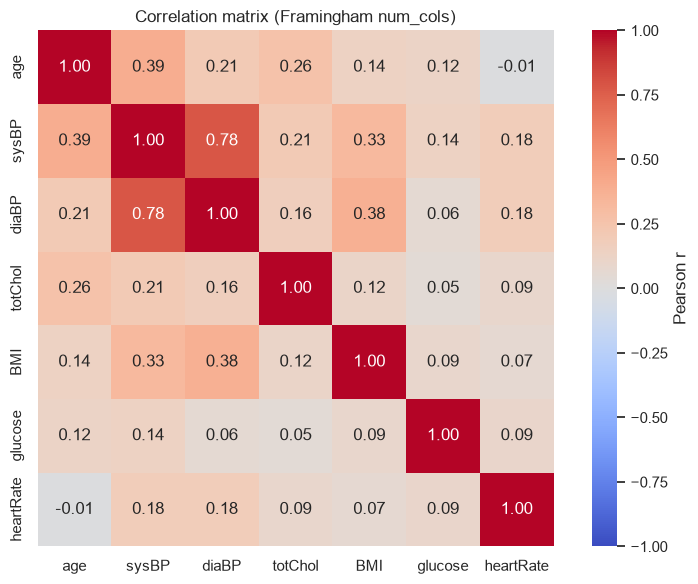


age - sysBP 상관계수 : 0.394
sysBP - diaBP 상관계수: 0.784


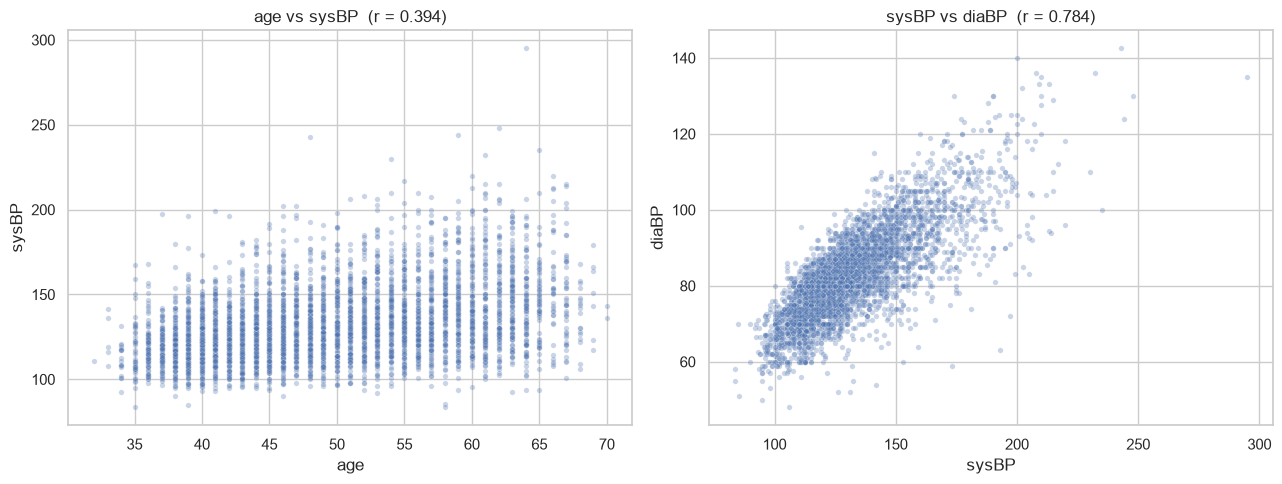

In [15]:
try:
    num_cols
except NameError:
    num_cols = ["age", "sysBP", "diaBP", "totChol", "BMI", "glucose", "heartRate"]

# 1) 상관행렬 계산 (연속형 변수만). Pearson 상관.
#    힌트: DataFrame에는 상관행렬을 바로 구하는 메서드가 있다.
corr = df[num_cols].corr(method="pearson") 
print("상관행렬 (Pearson):")
print(corr.round(3))

# 2) 히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,                       # TODO: 무엇을 히트맵으로 그릴까?
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    vmin=-1, vmax=1, square=True,
    cbar_kws={"label": "Pearson r"},
)
plt.title("Correlation matrix (Framingham num_cols)")
plt.tight_layout()
plt.show()

# 3) 관심 상관 두 개를 명시적으로 추출 (해석 질문에서 인용할 값)
#    힌트: corr는 행/열이 변수명인 표 → .loc[행, 열] 로 특정 칸을 꺼낸다.
corr_age_sysBP = corr.loc["age", "sysBP"]
corr_sysBP_diaBP = corr.loc["sysBP", "diaBP"]
print(f"\nage - sysBP 상관계수 : {corr_age_sysBP:.3f}")
print(f"sysBP - diaBP 상관계수: {corr_sysBP_diaBP:.3f}")

# 4) 산점도 두 장: (a) age vs sysBP, (b) sysBP vs diaBP
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="age", y="sysBP", alpha=0.3, s=15, ax=axes[0])  # TODO: age vs sysBP
axes[0].set_title(f"age vs sysBP  (r = {corr_age_sysBP:.3f})")
axes[0].set_xlabel("age")
axes[0].set_ylabel("sysBP")

sns.scatterplot(data=df, x="sysBP", y="diaBP", alpha=0.3, s=15, ax=axes[1])  # TODO: sysBP vs diaBP
axes[1].set_title(f"sysBP vs diaBP  (r = {corr_sysBP_diaBP:.3f})")
axes[1].set_xlabel("sysBP")
axes[1].set_ylabel("diaBP")

plt.tight_layout()
plt.show()


**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요)**

1. **age–sysBP 상관계수를 소수 셋째 자리까지** 적으세요. 부호(+/−)와 크기를 근거로 나이와 수축기 혈압의 관계를 한 문장으로 설명하세요. (예: "내 값은 0.___ 이고, 양수이므로 …")

    답: 제 값은 0.394이고, 양수이므로 나이가 들수록 수축기 혈압이 증가하는 경향이 있지만 그 강도가 매우 강하지는 않습니다.

2. **sysBP–diaBP 상관계수**는 얼마였나요? 이 값이 age–sysBP 상관보다 훨씬 큰 이유는 무엇인가요? 이렇게 닮은 두 변수를 **다중회귀에 함께** 넣으면 생기는 공선성 문제를, 히트맵이 어떻게 "예고"하는지 본인 값으로 서술하세요.

    답: 제 값은 0.784이고, 수축기혈압(sysBP)와 이완기혈압(diaBP)은 둘다 혈압을 나타내는 변수이기 때문에 매우 강한 상관관계를 가져 당연히 age-sysBP 상관보다 훨씬 큽니다. 이렇게 닮은 두 변수를 다중회귀에 함께 넣을 경우 다중공선성 문제가 발생하게 되는데, 위 히트맵에서 볼 수 있듯이 diaBP와 sysBP의 상관계수는 0.784로 진한 색으로 나와 있어 공선성 문제가 생길 수 있음을 미리 예측할 수 있습니다.

3. ⚠️ 오개념 점검: 두 변수의 상관이 0.02로 작게 나왔다면 "두 변수는 아무 관계가 없다"고 결론지어도 될까요? 산점도를 함께 봐야 하는 이유와 연결해 답하세요.

    답: 두 변수의 상관이 작게 나왔을 때 두 변수는 무관하다고 단정지으면 안 됩니다. 이 문제에서 사용한 피어슨 상관계수는 선형 관계만 측정하므로 비선형 관계가 존재하면 상관계수가 작게 나올 수 있습니다. 따라서 산점도를 함께 봐서 비선형 패턴 등을 확인해야 합니다.


### 1.3 표본분포와 중심극한정리(CLT) 시뮬레이션 — 손으로 직접 짜기

앞 절의 `sysBP`(수축기 혈압) 전체 값을 이번엔 **'모집단(population)'** 이라 상상합니다. 모집단 전체는 볼 수 없어 매번 **일부만 표본으로 뽑아** 평균을 냅니다. 이 "표본 뽑아 평균 내기"를 수천 번 반복하면, 그 **표본평균들이 그리는 분포**(= 표본분포, sampling distribution)에 규칙이 나타납니다.

- **표본분포:** 같은 크기 `n`의 표본을 반복해 뽑아 매번 낸 **평균값들**이 이루는 분포. 데이터 자체가 아니라 "평균의 분포"입니다.
- **중심극한정리(CLT):** 모집단이 정규분포가 아니어도 `n`이 커지면 표본평균 분포는 **정규분포에 가까워지고**, 그 **표준편차(= 표준오차)는 $\sigma/\sqrt{n}$** 으로 줄어듭니다. `sysBP`는 $\sigma \approx 22$입니다.
- 직관: `n`이 커질수록 극단값이 상쇄돼 평균이 **덜 흔들려**, 히스토그램이 더 좁고 종 모양에 가까워집니다.

`np.random.choice` 같은 표본추출 함수는 써도 되지만, **"반복해서 평균을 모으는 루프"는 직접 `for` 루프로 구현**하세요. "표본을 뽑는다 → 평균을 낸다 → 리스트에 담는다 → reps번 반복" 흐름을 손으로 익히는 게 목표입니다.


모집단 크기 = 4240,  모집단 평균 = 132.35,  모집단 표준편차(sigma) = 22.03


C:\Users\juhye\AppData\Local\Temp\ipykernel_33308\891466487.py:35: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juhye\AppData\Local\Temp\ipykernel_33308\891466487.py:35: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juhye\AppData\Local\Temp\ipykernel_33308\891466487.py:35: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juhye\AppData\Local\Temp\ipykernel_33308\891466487.py:35: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juhye\AppData\Local\Temp\ipykernel_33308\891466487.py:35: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juhye\AppData\Local\Temp\ipykernel_33308\891466487.py:35: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layo

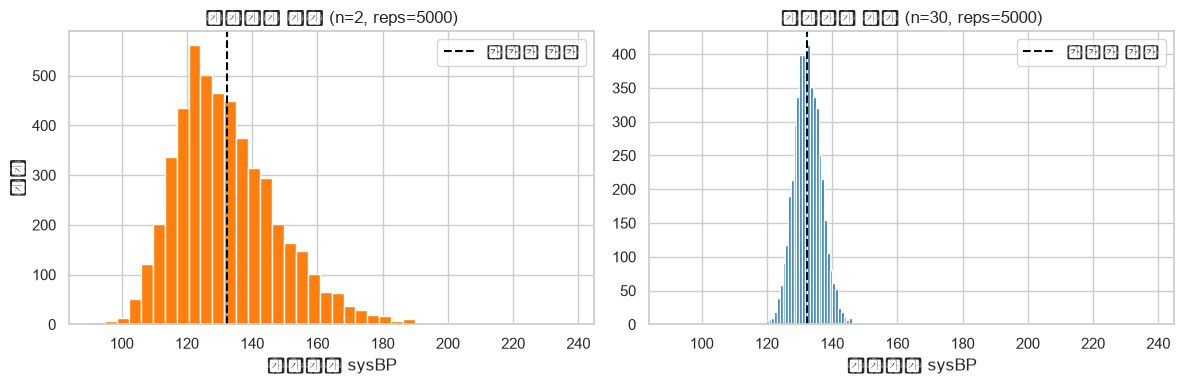

n= 2 | 경험 표준편차 = 15.674 | 이론값 sigma/sqrt(n) = 15.578
n=30 | 경험 표준편차 = 4.150 | 이론값 sigma/sqrt(n) = 4.022


In [16]:
# --- 0) 재현성: 시드 고정 ---
np.random.seed(MY_SEED)

# --- 1) sysBP 전체 값을 '모집단'으로 사용 (결측 제거) ---
pop = df["sysBP"].dropna().values          # TODO: 결측 제거 메서드
sigma = pop.std(ddof=0)                 # 모집단 표준편차 ~ 22
print(f"모집단 크기 = {len(pop)},  모집단 평균 = {pop.mean():.2f},  모집단 표준편차(sigma) = {sigma:.2f}")

# --- 2) 표본평균을 모으는 헬퍼: 직접 for 루프로 구현 (라이브러리에 통째로 맡기지 말 것!) ---
def sample_means(data, n, reps):
    means = []
    for _ in range(reps):
        sample = np.random.choice(data, size=n, replace=True)                   # TODO: data에서 크기 n 표본을 복원추출 (np.random.choice, replace=True)
        means.append(np.mean(sample))              # TODO: 그 표본의 평균을 기록
    return np.array(means)

# --- 3) n=2 vs n=30 으로 표본분포 만들기 ---
reps = 5000
means_n2  = sample_means(pop, n=2,  reps=reps)
means_n30 = sample_means(pop, n=30, reps=reps)

# --- 4) 두 히스토그램 나란히 비교 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].hist(means_n2, bins=40, color="tab:orange", edgecolor="white")
axes[0].axvline(pop.mean(), color="black", linestyle="--", label="모집단 평균")
axes[0].set_title(f"표본평균 분포 (n=2, reps={reps})")
axes[0].set_xlabel("표본평균 sysBP"); axes[0].set_ylabel("빈도"); axes[0].legend()

axes[1].hist(means_n30, bins=40, color="tab:blue", edgecolor="white")
axes[1].axvline(pop.mean(), color="black", linestyle="--", label="모집단 평균")
axes[1].set_title(f"표본평균 분포 (n=30, reps={reps})")
axes[1].set_xlabel("표본평균 sysBP"); axes[1].legend()

plt.tight_layout()
plt.show()

# --- 5) 경험 표준편차(표준오차) vs 이론값 sigma/sqrt(n) 비교 ---
for n, means in [(2, means_n2), (30, means_n30)]:
    emp = means.std(ddof=0)             # 시뮬레이션으로 얻은 표본평균들의 표준편차
    theo = sigma / np.sqrt(n)         # TODO: CLT 이론값 = sigma / sqrt(n)
    print(f"n={n:>2} | 경험 표준편차 = {emp:.3f} | 이론값 sigma/sqrt(n) = {theo:.3f}")


**해석 질문 (본인이 출력한 실제 숫자를 인용해 답하세요):**

1. `n=2`와 `n=30`의 히스토그램을 비교하세요. 어느 쪽이 더 좁고 종 모양에 가까웠나요? 두 분포의 중심은 모집단 평균(약 132)과 견주어 어디쯤이었나요?

    답: n=30일 때의 히스토그램이 더 좁고 종 모양에 가깝습니다. 두 분포의 중심 모두 모집단 평균(약 132) 부근에 위치해 있습니다.

2. 5번 셀의 **경험 표준편차** 두 값을 적고, 각각을 **이론값 $\sigma/\sqrt{n}$**($\sigma \approx 22$이므로 $22/\sqrt{2} \approx 15.6$, $22/\sqrt{30} \approx 4.0$)과 비교하세요. `n`이 2에서 30으로 커질 때 표본평균의 흔들림(표준오차)은 어떻게 변했나요?

    답: n=2일 때의 경험 표준편차 값은 15.674이고, n=3일 때의 경험 표준편차 값은 4.150이며 이론값은 각각 15.578과 4.022입니다. 두 경우 모두 경험 표준편차 값과 이론값이 비슷하고 `n`이 2에서 30으로 커질 때 표준오차는 감소하여 표본평균의 흔들림이 줄어드는 것을 확인할 수 있습니다.

3. 위 결과를 **중심극한정리(CLT)** 한 문장으로 요약하세요. (힌트: "표본크기 n이 커지면 표본평균의 분포는 ___에 가까워지고, 그 표준편차는 ___으로 줄어든다.")

    답: 표본크기 n이 커지면 표본평균의 분포는 정규분포에 가까워지고, 그 표준편차는 $\sigma/\sqrt{n}$ 에 따라 줄어듭니다.

> ⚠️
> - **"표준편차가 줄어든다 = 데이터가 덜 퍼진다"가 아닙니다.** 모집단(개별 sysBP)의 퍼짐 $\sigma \approx 22$는 그대로이고, 줄어드는 건 **표본평균**의 퍼짐(=표준오차 $\sigma/\sqrt{n}$)입니다.
> - **CLT는 표본크기 n에 대한 규칙이지 반복횟수 reps에 대한 규칙이 아닙니다.** reps를 늘리면 히스토그램이 매끄러워질 뿐, 폭(표준오차)은 `n`이 결정합니다. 폭을 줄이려면 `reps`가 아니라 `n`을 키워야 합니다.


### 1.4 신뢰구간 — 부트스트랩으로 sysBP 평균의 95% CI 직접 만들기

신뢰구간(confidence interval, CI)은 표본으로 추정한 값이 얼마나 흔들릴 수 있는가를 구간으로 나타낸 것입니다. sysBP 평균을 하나의 숫자(점추정)로 봤지만, 표본이 바뀌면 그 평균도 달라지고, 그 흔들림의 폭을 잡아주는 것이 CI입니다.

**부트스트랩(bootstrap)** 은 그 흔들림을 공식 없이 **재표집(resampling)** 으로 흉내 내는 방법입니다.

1. 데이터(pop, 크기 n)에서 **복원추출(replacement=중복 허용)** 로 n개를 다시 뽑습니다 → 새 표본 1개
2. 그 표본의 **평균**을 기록합니다
3. 1~2를 reps번(예: 2000번) 반복 → 평균이 reps개 쌓입니다(boot_means)
4. 이 평균들의 **2.5 백분위 ~ 97.5 백분위** 사이가 95% CI

핵심은 복원추출입니다. 같은 값을 여러 번 뽑을 수 있어야 매번 다른 표본이 되고, 그 다름이 평균의 흔들림이 됩니다. 이번 유형 A에서는 이 재표집 루프를 `scipy.stats.bootstrap`에 맡기지 말고 **손으로 직접** 짭니다.

한 줄 풀이 — **백분위(percentile)**: 값들을 크기순으로 늘어놓을 때 아래에서 몇 % 지점에 오는 값. 2.5 백분위와 97.5 백분위 사이에 가운데 95%가 들어갑니다.


관측된 sysBP 평균 (점추정): 132.35
부트스트랩 95% 신뢰구간: [131.69, 133.02]


C:\Users\juhye\AppData\Local\Temp\ipykernel_33308\2615474603.py:35: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juhye\AppData\Local\Temp\ipykernel_33308\2615474603.py:35: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) Arial.
  plt.tight_layout()


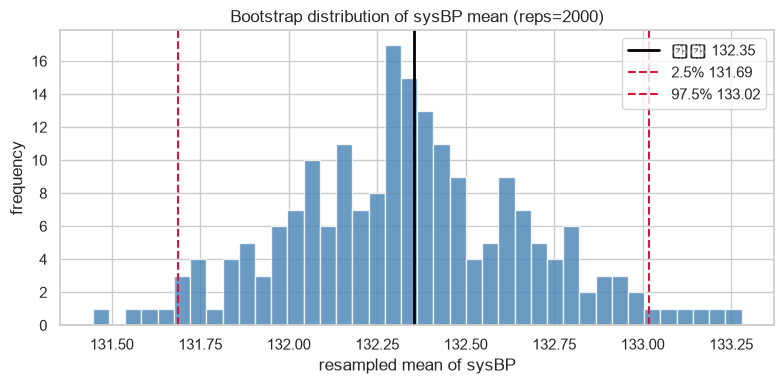

In [17]:
# === 1.4 신뢰구간: sysBP 평균의 95% CI를 부트스트랩으로 직접 구현 ===
# pop 은 1.3에서 만든 전체 sysBP 값 배열입니다. (없다면 아래 한 줄로 복구)
pop = df["sysBP"].dropna().values

n = len(pop)          # 표본 크기 (매 재표집도 이 크기로 뽑는다)
reps = 200           # 재표집 반복 횟수
rng = np.random.default_rng(MY_SEED)   # 재현 가능한 난수 생성기

# 부트스트랩 평균들을 담을 그릇
boot_means = np.empty(reps)

for i in range(reps):
    # TODO: pop 에서 복원추출(중복 허용)로 n개 인덱스를 뽑아라 (힌트: rng.integers)
    idx = rng.integers(low=0, high=n, size=n)
    resample = pop[idx]
    # TODO: 그 표본의 평균을 boot_means[i] 에 기록하라
    boot_means[i] = np.mean(resample)

# TODO: boot_means 에서 2.5 / 97.5 백분위를 잘라 ci_low, ci_high 로 받아라
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

print(f"관측된 sysBP 평균 (점추정): {pop.mean():.2f}")
print(f"부트스트랩 95% 신뢰구간: [{ci_low:.2f}, {ci_high:.2f}]")

# 부트스트랩 평균들의 분포 + CI 시각화 (보일러플레이트 — 그대로 두세요)
plt.figure(figsize=(8, 4))
plt.hist(boot_means, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(pop.mean(), color="black", linestyle="-", linewidth=2, label=f"평균 {pop.mean():.2f}")
plt.axvline(ci_low,  color="crimson", linestyle="--", linewidth=1.5, label=f"2.5% {ci_low:.2f}")
plt.axvline(ci_high, color="crimson", linestyle="--", linewidth=1.5, label=f"97.5% {ci_high:.2f}")
plt.title("Bootstrap distribution of sysBP mean (reps=2000)")
plt.xlabel("resampled mean of sysBP")
plt.ylabel("frequency")
plt.legend()
plt.tight_layout()
plt.show()


**해석 질문 (본인이 출력한 실제 숫자를 인용해 답하세요)**

1. 방금 얻은 신뢰구간 `[ci_low, ci_high]`의 실제 값을 적으세요. 강의에서 예고한 대략 [131.7, 133.0]과 비슷한가요? (`MY_SEED`·reps에 따라 소수점은 달라집니다.)

   답: 신뢰구간은 [131.69, 133.06]입니다. 강의에서 예고한 [131.7, 133.0]과 비슷합니다.

2. **빈도주의 해석을 정확히 쓰세요.** 다음 두 문장 중 옳은 것은 무엇이고, 왜 나머지는 틀렸는지 본인 CI 값을 넣어 설명하세요.
   - (A) "CI를 만드는 절차를 무한히 반복하면, 그 구간들 중 약 95%가 진짜 모평균을 포함한다."
   - (B) "진짜 sysBP 모평균이 내 구간 안에 있을 확률이 95%다."

   → 정답은 (A). 빈도주의에서 모평균은 고정값이고 무작위로 흔들리는 것은 **구간** 쪽이라, 확률 95%는 "이 특정 구간"이 아니라 "구간을 만드는 절차 전체"에 붙습니다. 이미 계산된 내 구간 하나는 참값을 포함했거나 안 했거나 둘 중 하나이므로, 여기에 95% 확률을 매기는 (B)는 베이지안식 표현이라 부정확합니다.

   답: 옳은 문장은 (A)입니다. 모평균은 하나의 고정된 값이고 구한 신뢰구간 [131.69, 133.06]은 모평균을 포함하거나 포함하지 않는 것이지 이 특정 구간에 95%라는 확률을 부여할 수는 없기 때문입니다.

3. reps를 200으로 줄이면 CI 폭과 히스토그램 모양이 어떻게 달라질지 예상하고, 실제로 바꿔 실행해 확인하세요. (재표집 횟수는 CI의 '안정성'에 영향을 줄 뿐, 데이터 자체의 불확실성을 줄이지는 않습니다.)

   답: reps를 200으로 줄이면 표본 수가 감소하니까 히스토그램이 덜 매끄러운 모양이 되고, 재표집 횟수가 줄어들어 CI의 안정성이 떨어지긴 하지만 폭이 달라지지는 않습니다.


### 1.5 두 집단 평균차 t검정 (유형 B)

이제 CHD 발병군과 비발병군의 수축기 혈압(sysBP)이 정말 다른지 통계적으로 검정합니다. **두 집단 평균차 t검정(two-sample t-test)** 은 "두 집단 평균이 같다(차이=0)"는 **귀무가설 $H_0$** 을, 관측된 평균차가 우연만으로 나올 확률(**p값**)로 판단합니다.

**왜 Welch t인가요?** 기본형(Student t)은 두 집단 분산이 같다고 가정하지만, 여기서는 두 군의 sysBP 표준편차가 다릅니다(CHD군 $\approx 26.7$ vs 비CHD군 $\approx 20.5$). 분산이 다를 때는 **Welch t검정**(`equal_var=False`)이 자유도를 보정해 더 정확합니다.

**p값 한 줄 풀이:** $H_0$(차이 없음)이 참이라고 가정했을 때, 지금 본 것만큼 또는 그보다 더 극단적인 평균차가 우연히 관측될 확률입니다. 작을수록(관례상 < 0.05) $H_0$ 기각.

**주의 — 유의성 ≠ 크기.** p값은 "차이가 0이 아니다"만 말할 뿐 **차이가 얼마나 큰지**는 말하지 않습니다. n이 크면 아주 작은 차이도 p가 극단적으로 작아지므로, p값과 함께 **효과크기(평균차 자체)** 를 반드시 같이 봐야 합니다.


In [18]:
# 1.5 두 집단 평균차 t검정 (Welch) ----------------------------------
# TenYearCHD == 1 (10년 내 CHD 발생) vs == 0 각각의 sysBP (결측 제거)
g1 = df.loc[df["TenYearCHD"] == 1, "sysBP"].dropna().values   # CHD 발생군
g0 = df.loc[df["TenYearCHD"] == 0, "sysBP"].dropna().values                    # TODO: 비발생군 조건

print(f"CHD군    (n={len(g1)}): 평균 {g1.mean():.1f}, 표준편차 {g1.std(ddof=1):.1f}")
print(f"비CHD군  (n={len(g0)}): 평균 {g0.mean():.1f}, 표준편차 {g0.std(ddof=1):.1f}")

# 두 군의 분산이 다르므로(26.7 vs 20.5) Welch t검정
# TODO: stats.ttest_ind 로 Welch t검정 (분산 다름 옵션을 꼭 넣을 것)
t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)

mean_diff = g1.mean() - g0.mean()   # 효과크기: 평균차
print(f"\n평균차(효과크기) = {mean_diff:.1f} mmHg")
print(f"Welch t = {t_stat:.2f},  p = {p_val:.2e}")

if p_val < 0.05:
    print("=> p < 0.05: 귀무가설(두 군 평균 같다) 기각")
else:
    print("=> p >= 0.05: 귀무가설 기각 실패")


CHD군    (n=644): 평균 143.6, 표준편차 26.7
비CHD군  (n=3596): 평균 130.3, 표준편차 20.5

평균차(효과크기) = 13.3 mmHg
Welch t = 12.01,  p = 1.25e-30
=> p < 0.05: 귀무가설(두 군 평균 같다) 기각


**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요)**

1. `t_stat`과 `p_val`은 각각 얼마인가요? 이 p값으로 "두 군의 sysBP 평균은 같다"는 귀무가설을 **기각하나요, 기각에 실패하나요?** 한 문장으로 판정하세요.

   답: `t_stat`은 12.01이고, `p_val`은 1.25e-30입니다. p-value가 0.05보다 훨씬 작으므로 귀무가설을 기각합니다.

2. p값을 "두 군의 sysBP가 우연히 이만큼 차이 날 확률"이라 하면 왜 부정확한가요? p값의 정의(귀무가설이 참이라 **가정했을 때** 이만큼 극단적인 결과가 나올 확률)를 살려 고쳐 쓰세요.
   - (오개념 주의) p값은 "귀무가설이 참일 확률"이 **아닙니다.**
      
   답: p-value는 귀무가설이 참이라 가정했을 때 13.3 또는 더 극단적인 결과가 나올 확률을 의미하기 때문에 두 군의 sysBP가 우연히 이만큼 차이 날 확률이라고 쓰면 부정확합니다.

3. p값이 작다는 것만으로 "혈압 차이가 임상적으로 크다"고 결론 낼 수 있나요? 출력한 **평균차($\approx 13.3$ mmHg)** 를 인용해, p값(유의성)과 효과크기를 **왜 둘 다** 봐야 하는지 설명하세요. (n이 크면 작은 평균차도 p가 극단적으로 작아짐)

   답: 없습니다. p-value는 통계적으로 유의한지만 알려주는 것이지 차이가 크다는 것을 의미하지는 않습니다. 이 결과에서 p-value가 매우 작아 통계적으로 유의하지만 평균차는 13.3입니다. n이 크면 작은 평균차도 p값이 극단적으로 작아지기 때문에 결과를 해석할 때는 p값으로 유의성을 확인하고, 효과크기를 둘다 봐야 합니다.

4. `equal_var=False`(Welch)를 쓴 이유를 두 군의 **표준편차($\approx 26.7$ vs $\approx 20.5$)** 를 인용해 한 문장으로 답하고, `equal_var=True`로 바꾸면 무엇이 달라질지 예상하세요.

   답: 두 군의 표준편차, 즉 분산이 다르기 때문에 Welch t검정을 사용하였습니다. `equal_var=True`로 바꾸면 Student t검정이 수행되며 자유도와 p값이 약간 달라질수는 있지만 결론이 크게 달라지지는 않습니다.


### 1.6 단순선형회귀 (Simple Linear Regression)

두 변수의 관계를 **직선 하나로 요약**합니다. 1.5의 집단 비교에서 나아가, **"나이가 1살 늘면 수축기혈압(sysBP)은 평균 몇 mmHg 변하는가?"** 라는 연속적 관계의 크기를 답합니다.

- **단순선형회귀:** 설명변수 x(`age`) 하나로 반응변수 y(`sysBP`)를 $y \approx \beta_0 + \beta_1 \cdot x$ 직선으로 예측하는 모형. $\beta_1$(기울기)이 "x 1단위 증가 시 y의 평균 변화량".
- **OLS(최소제곱법):** 실제 값과 예측값의 차이(잔차)를 제곱해 합한 값을 **최소로** 만드는 $\beta_0, \beta_1$을 찾는 방법. `smf.ols`가 계산해 줍니다.
- **`smf.ols("sysBP ~ age", ...)`:** `~` 왼쪽이 y, 오른쪽이 x인 **R 스타일 공식** 문법. `.fit()`을 붙여야 계수가 추정됩니다.
- **$R^2$(결정계수):** 모형이 y의 전체 변동 중 몇 %를 설명하는지를 0~1로 나타냄. $R^2=0.155$면 sysBP 변동의 약 15.5%를 나이만으로 설명한다는 뜻. **상관계수($\approx 0.394$)를 제곱하면 $R^2$** — 단순회귀에서 $R^2 = r^2$.
- **계수의 p값·95% 신뢰구간:** 기울기 $\beta_1$에도 t검정 논리가 적용됩니다. "진짜 기울기가 0(관계 없음)"이라는 귀무가설을 검정하고 $\beta_1$의 범위를 95% CI로 제시. CI가 0을 포함하지 않으면 유의합니다.

> 참고: `age`·`sysBP`는 결측이 없어 이 절에서는 별도 dropna가 필요 없습니다.


                            OLS Regression Results                            
Dep. Variable:                  sysBP   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     779.0
Date:                Tue, 28 Jul 2026   Prob (F-statistic):          1.58e-157
Time:                        03:34:06   Log-Likelihood:                -18770.
No. Observations:                4240   AIC:                         3.754e+04
Df Residuals:                    4238   BIC:                         3.756e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     82.1420      1.826     44.992      0.0

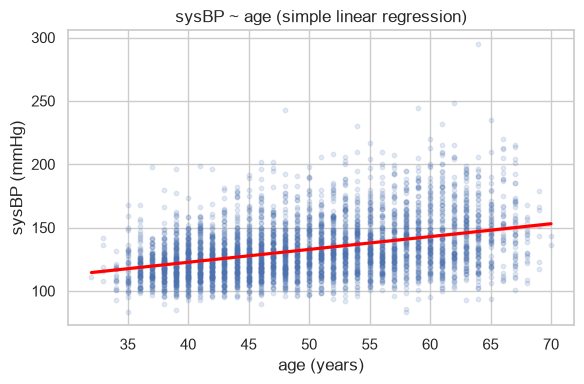

In [20]:
# age(설명변수) 하나로 sysBP(반응변수)를 예측하는 단순선형회귀
# TODO: "반응변수 ~ 설명변수" 공식으로 OLS 모형을 적합하세요 (.fit()까지)
model_simple = smf.ols("sysBP ~ age", data=df).fit()

# 회귀 결과 전체 요약표: 계수, 표준오차, t, p값, 95% CI, R^2 등
print(model_simple.summary())

# 핵심 값만 뽑아 보기
beta_age = model_simple.params["age"]          # age 기울기 계수
p_age    = model_simple.pvalues["age"]         # age 계수의 p값
ci_age   = model_simple.conf_int().loc["age"]  # age 계수의 95% 신뢰구간 [하한, 상한]
# TODO: 모형의 결정계수(R^2)를 꺼내세요 (model_simple 의 속성)
r2       = model_simple.rsquared

print(f"\nage 계수(기울기)  = {beta_age:.4f} mmHg / 1살")
print(f"age 계수 p값       = {p_age:.3e}")
print(f"age 계수 95% CI    = [{ci_age[0]:.4f}, {ci_age[1]:.4f}]")
print(f"R^2               = {r2:.4f}")

# 단순회귀에서 R^2 = (상관계수)^2 임을 직접 확인
r = df["age"].corr(df["sysBP"])
print(f"\ncorr(age, sysBP)  = {r:.4f},  r^2 = {r**2:.4f}  (== R^2)")

# 산점도 + 회귀직선으로 관계 시각화
plt.figure(figsize=(6, 4))
sns.regplot(x="age", y="sysBP", data=df,
            scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"})
plt.title("sysBP ~ age (simple linear regression)")
plt.xlabel("age (years)")
plt.ylabel("sysBP (mmHg)")
plt.tight_layout()
plt.show()


**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요):**

1. 본인이 얻은 `age` 계수는 얼마입니까? 문장으로 옮겨 보세요: "나이가 1살 많아질수록 수축기혈압(sysBP)은 평균 약 ____ mmHg 높아진다."

    답: 나이가 1살 많아질수록 수축기혈압(sysBP)은 평균 약 1.0128mmHg 높아집니다.

2. `age` 계수의 p값과 95% 신뢰구간을 인용하세요. 이 CI가 **0을 포함하는지** 확인하고, 그것이 "나이와 혈압 사이에 관계가 있다"는 주장과 어떻게 연결되는지 한 문장으로 설명하세요.

    답: `age` 계수의 p값은 1.58e-157로 매우 작아 통계적으로 유의합니다. 또한 95% 신뢰구간은 [0.9416, 1.0839]으로 0을 포함하지 않으므로 나이와 수축기혈압 사이엔 통계적으로 유의한 양의 관계가 있습니다.

3. 본인의 $R^2$는 얼마입니까? `corr(age, sysBP)`의 제곱과 같은 값이 나왔나요? "$R^2$ = ____ 이므로, 나이만으로 sysBP 변동의 약 ____%를 설명한다"를 채워 쓰세요.

    답: 내 $R^2$ 값은 0.1553이고, `corr(age, sysBP)`의 제곱과 같은 값이 나왔으므로 나이만으로 sysBP 변동의 약 15.53%를 설명합니다.

**오개념 주의:**
- ❌ "$R^2$가 0.155니까 모형이 나쁘다" → $R^2$가 낮다고 관계가 없는 건 아닙니다. 계수의 p값($\approx 10^{-157}$)은 관계가 확실함을 보여줍니다. $R^2$는 설명력, p값은 관계의 존재 여부로 서로 다른 질문입니다.
- ❌ "나이가 혈압을 올린다(인과)" → 계수는 **연관(상관)**의 크기일 뿐, 이 관측 데이터만으로 인과를 증명하지 못합니다.
- ❌ 계수 단위 빼먹기 → 기울기의 단위는 **mmHg / 1살**입니다.


### 1.7 다중회귀 — 여러 변수로 sysBP 설명하기 (범주형 포함)

단순회귀(1.6)는 `age` 하나로 `sysBP`를 설명했습니다. 혈압은 나이만으로 정해지지 않고 BMI·콜레스테롤·혈당·성별·흡연·당뇨 등이 함께 작용합니다. **다중회귀(multiple regression)**는 여러 예측변수를 한 모델에 넣어 "다른 변수를 고정했을 때 각 변수가 sysBP에 주는 순효과(partial effect)"를 추정합니다.

- **연속형 변수**(`age`, `BMI`, `totChol`, `glucose`)는 그대로 넣습니다.
- **범주형 변수**(`male`, `currentSmoker`, `diabetes`)는 0/1 코드지만 숫자 크기에 의미가 없어 `C(...)`로 감싸 **더미(dummy) 변수**로 처리합니다. `C(male)`은 "여성(0) 대비 남성(1)의 sysBP 차이"를 계수로 줍니다.

**결측(NaN) 자동 제거 주의:** 이 모델에는 `glucose`(388개)·`totChol`(50개)·`BMI`(19개) 등 결측 있는 열이 들어갑니다. statsmodels는 formula에 쓰인 열 중 **하나라도 NaN인 행을 통째로 제외**(listwise deletion)하므로, 전체 4,240행보다 **실제 쓰인 n이 줄어듭니다**(`model_multi.nobs`로 확인). 넣는 변수에 따라 표본 크기가 달라지는 것이 결측 데이터의 핵심 함정입니다.

**$R^2$는 단순회귀보다 오릅니다:** 설명변수를 늘리면 모델이 잡는 분산이 늘어 $R^2$가 상승합니다. 다만 변수를 넣을수록 $R^2$는 기계적으로 커지는 성질이 있음에 주의합니다.


In [21]:
# 1.7 다중회귀 (범주형 포함)
# 연속형(age, BMI, totChol, glucose) + 범주형은 C(...)로 감싸 더미 처리
# statsmodels가 NaN 행을 자동 제외 → 실제 n이 줄어드는 점에 주의

# TODO: sysBP를 age, BMI, totChol, glucose(연속형) + male, currentSmoker, diabetes(범주형)로 설명하는 OLS
#       범주형 세 변수는 반드시 C(...)로 감쌀 것
model_multi = smf.ols(
    "sysBP ~ age + BMI + totChol + glucose + C(male) + C(currentSmoker) + C(diabetes)",
    data=df
).fit()

print(model_multi.summary())

# 결측 자동 제거로 실제 사용된 표본 크기 확인
print(f"\n전체 행수: {len(df)}")
print(f"다중회귀에 실제 사용된 n(nobs): {int(model_multi.nobs)}")   # TODO: model_multi에서 nobs 속성 사용
print(f"→ 결측으로 {len(df) - int(model_multi.nobs)}개 행 제외됨")

# 단순회귀(1.6) 대비 R² 상승 확인
print(f"\n단순회귀(age만) R²   = {model_simple.rsquared:.3f}")
print(f"다중회귀 R²          = {model_multi.rsquared:.3f}")   # TODO: model_multi의 R²
print(f"다중회귀 Adjusted R² = {model_multi.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                  sysBP   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     177.5
Date:                Tue, 28 Jul 2026   Prob (F-statistic):          3.63e-228
Time:                        04:32:16   Log-Likelihood:                -16739.
No. Observations:                3828   AIC:                         3.349e+04
Df Residuals:                    3820   BIC:                         3.354e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                39.04

**Q. 다중회귀 결과를 확인하세요.**

1. `model_multi.nobs`는 전체 4,240에서 얼마로 줄었나요? **본인 값**을 적고, 왜 줄었는지 한 줄로 설명하세요.

    답: `model_multi.nobs`는 전체 4240에서 3828로 줄었습니다. 이는 결측치가 포함된 행들이 삭제되었기 때문입니다.

2. `age` 계수가 단순회귀(1.6)와 다중회귀에서 달라졌나요? 어느 쪽이 더 크고 왜 그럴 수 있을까요? (다른 변수를 '통제'한다는 것과 연결해 설명하세요.)

    답: `age` 계수는 단순회귀에서 1.0128이었고, 다중회귀에서는 0.8183으로 다중회귀에서 더 작습니다.이는 다중회귀에서는 여러 변수들을의 영향을 함께 통제한 상태에서 나이의 순수한 효과만 추정하기 때문입니다.


### 1.8 해석(explain) vs 예측(predict) — train/test로 갈라 보기

지금까지의 회귀(1.6~1.7, `smf.ols`)는 대부분 **해석(explanation)** 관점이었습니다("계수가 유의한가?", "분산을 얼마나 설명하나($R^2$)?"). 이때 $R^2$는 **학습에 쓴 그 데이터(in-sample)** 위에서 계산됩니다.

또 다른 질문도 있습니다: **"새 환자의 sysBP를 얼마나 잘 맞힐까?"** — **예측(prediction)** 관점입니다. 예측 성능은 **본 적 없는 데이터**에서 재야 공정하며, 학습 데이터로 재면 성능이 부풀려집니다.

그래서 데이터를 둘로 나눕니다.
- **train(훈련) 세트**: 계수를 배우는 데이터.
- **test(테스트) 세트**: 학습에 쓰지 않고 마지막에 성능만 재는 데이터.

예측 오차 지표:
- **RMSE (평균제곱근오차)**: 오차를 제곱·평균 후 제곱근. 큰 오차에 더 큰 벌점. 단위는 예측 대상과 같음(mmHg).
- **MAE (평균절대오차)**: 오차 절댓값의 평균. 이상치에 덜 민감.

둘 다 **작을수록 좋고**, 항상 $\mathrm{RMSE} \ge \mathrm{MAE}$ 입니다. 둘의 **간격이 크면** 크게 빗나간 예측(큰 잔차)이 있다는 신호입니다.

주의: **예측 대상(sysBP)** 자체나 사실상 같은 정보를 X에 넣으면 **데이터 누수(leakage)**로 test 성능이 비현실적으로 좋아집니다. 그래서 sysBP는 y로만 쓰고 X에서는 뺍니다.

이 "해석이냐 예측이냐" 구분이 리뷰 논문 Shmueli, "To Explain or to Predict?" (2010)의 핵심입니다. 같은 회귀식이라도 **무엇을 묻느냐**에 따라 좋은 모델·지표가 달라집니다.


In [22]:
# === 1.8 해석 vs 예측: train/test 분할로 예측 성능 재기 ===
# 관점 전환: 1.6~statsmodels R²(in-sample, 해석) → 여기선 sklearn으로
# "처음 보는 test 데이터"에서의 예측 오차(RMSE·MAE)를 잰다.

# --- (1) 설계행렬 만들기 ---
target = "sysBP"
# TODO: 누수 방지 — sysBP(target)만 빼고 나머지를 설명변수 후보로. ____
feature_cols = [c for c in df.columns if c != target]

# 결측이 있으면 학습이 안 된다 → 설명변수+목표를 함께 놓고 결측 '행' 제거.
# TODO: 아래에서 결측 행을 통째로 제거하는 메서드를 채워라. ____
design = df[feature_cols + [target]].dropna()

# education만 원핫 인코딩(one-hot), 나머지는 숫자 그대로.
# TODO: education을 원핫하도록 인자를 채워라. ____
X = pd.get_dummies(design[feature_cols], columns=['education'], drop_first=True)
y = design[target]

print("사용한 행 수:", len(design), "/ 설명변수 개수:", X.shape[1])

# --- (2) train/test 분할 (재현 위해 random_state=MY_SEED) ---
# TODO: test 비율 0.2, random_state=MY_SEED 로 분할. ____
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=MY_SEED
)
print("train:", X_train.shape[0], " test:", X_test.shape[0])

# --- (3) 학습은 train에서만 ---
# TODO: train 데이터로만 적합. ____
lin = LinearRegression().fit(X_train, y_train)

# --- (4) 평가는 test에서만 ---
y_pred = lin.predict(X_test)
# TODO: RMSE = sqrt(MSE), MAE 를 test에서 계산. ____
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
mae  = metrics.mean_absolute_error(y_test, y_pred)

print(f"[예측 관점] test RMSE = {rmse:.3f} mmHg")
print(f"[예측 관점] test MAE  = {mae:.3f} mmHg")
print(f"RMSE - MAE 간격 = {rmse - mae:.3f}")

# --- (5) 해석 지표(in-sample R²)와 나란히 비교 ---
X_sm = sm.add_constant(X.astype(float))
ols_all = sm.OLS(y, X_sm).fit()
print(f"[해석 관점] in-sample R^2 = {ols_all.rsquared:.3f}")


사용한 행 수: 3658 / 설명변수 개수: 17
train: 2926  test: 732
[예측 관점] test RMSE = 11.183 mmHg
[예측 관점] test MAE  = 8.557 mmHg
RMSE - MAE 간격 = 2.625
[해석 관점] in-sample R^2 = 0.736


**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요)**

1. **test RMSE = ____ mmHg** 와 **MAE = ____ mmHg** 를 적으세요. 두 값 중 어느 쪽이 항상 더 크며 왜인가요? 둘의 간격($\mathrm{RMSE} - \mathrm{MAE}$)은 무엇을 알려주나요?

    답: test RMSE = 11.183 mmHg, test MAE = 8.557 mmHg입니다. 두 값 중 MAE가 항상 더 큰데, 그 이유는 RMSE는 오차를 제곱하고 평균 내기 때문입니다. 둘의 간격은 2.625로, 얼마나 큰 예측 오차가 존재하는지를 보여줍니다. 간격이 클수록 큰 오차의 영향이 더 크다는 뜻입니다.

2. RMSE는 "예측이 평균 약 몇 mmHg 빗나간다"로 읽습니다. 본인 RMSE를 sysBP의 표준편차($\approx 22$ mmHg)와 비교하면 어느 정도인가요? 이 모델은 **전체 평균으로 찍는 것보다 나은가요?**

    답: RMSE는 11.183 mmHg로, sysBP의 표준편차의 절반 정도로 작기 때문에 이 모델은 전체 평균으로 찍는 것보다 낫습니다. 

3. **$R^2$(in-sample)** 와 **test RMSE** 가 각각 답하는 질문을 한 문장씩 쓰세요. ($R^2$ → "데이터를 얼마나 잘 설명하나?", RMSE → "새 환자를 얼마나 잘 맞히나?") 이 구분이 리뷰 논문 Shmueli, *"To Explain or to Predict?"* 의 핵심입니다.

    답: $R^2$가 답하는 질문은 '모델이 학습 데이터의 변동을 얼마나 잘 설명하는가?'이고, test RMSE가 답하는 질문은 '학습에 사용하지 않은 새로운 데이터에서 예측이 평균적으로 얼마나 빗나가는가?'입니다.

4. "$R^2$이 높으면 예측도 잘한다"가 항상 맞나요? $R^2$을 **학습에 쓴 데이터에서** 재면 왜 예측 성능의 증거가 되기 어려운지, train/test 분할이 왜 필요했는지 본인 말로 설명하세요.

    답: 아닙니다. $R^2$ 은 학습 데이터에서의 설명력을 나타내므로 과적합이 일어날 경우 값이 높게 나올 수 있기 때문에 예측 성능의 증거가 되기 어렵습니다. 따라서 train/test 분할을 진행하여 예측 성능을 올바르게 평가해야 합니다.


## 2. 스스로 생각하기

여기까지는 "돌리면 나오는" 영역이었습니다. 진짜 실력은 **그 값을 어떻게 읽고 판단하느냐**에서 갈립니다. **직접 돌려서 나온 본인의 숫자**를 근거로, 그 숫자가 무엇을 의미하는지, 어디서 함정에 빠질 수 있는지 스스로 서술하세요. 남의 답을 베끼면 값이 안 맞아 바로 드러납니다.


### 2-A. 이진 반응에 선형회귀를 쓰면? — 로지스틱이 필요한 이유

지금까지 `sysBP`(연속형)를 선형회귀로 예측했지만, 이 데이터의 진짜 관심사는 10년 내 발병 여부 `TenYearCHD`(0/1)입니다.

`TenYearCHD`도 `smf.ols`로 예측하면 안 될까요? 선형회귀는 임의의 실수를 뱉지만 우리가 원하는 건 발병 확률(0~1)입니다. 둘이 맞는지 직접 돌려 확인합시다.

아래에서 `age`, `sysBP`, `BMI`로 `TenYearCHD`를 선형회귀한 뒤 예측값의 범위를 관찰합니다. (formula 방식이라 결측 행은 자동 제외됩니다.)


In [23]:
# 2-A. 진짜 관심사 TenYearCHD(0/1)를 '그냥' 선형회귀로 예측해 본다.
# (formula 방식은 결측이 있는 행을 자동으로 제외하고 적합한다.)
m_lpm = smf.ols("TenYearCHD ~ age + sysBP + BMI", data=df).fit()
pred = m_lpm.fittedvalues   # 각 사람에 대한 선형회귀 예측값

# TODO: 예측값의 최솟값과 최댓값을 출력하라.
print("예측값 min :", pred.min())
print("예측값 max :", pred.max())

# TODO: 예측값이 0보다 작은 사람 수, 1보다 큰 사람 수를 세어 출력하라.
n_below0 = int((pred < 0).sum())
n_above1 = int((pred > 1).sum())
print("0보다 작은 예측값을 받은 사람 수 :", n_below0)
print("1보다 큰 예측값을 받은 사람 수 :", n_above1)
print("적합에 실제로 쓰인 관측치 수 :", int(m_lpm.nobs))


예측값 min : -0.07071488414938024
예측값 max : 0.6461474980212303
0보다 작은 예측값을 받은 사람 수 : 89
1보다 큰 예측값을 받은 사람 수 : 0
적합에 실제로 쓰인 관측치 수 : 4221


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** 위 선형회귀의 예측값 중 0~1 범위를 벗어나는 사람이 있을지 없을지 한 줄로 먼저 적으세요.

    답: 일반적인 선형회귀는 출력값에 제한이 없으므로 0~1 범위를 벗어나는 사람이 있을수도 있습니다.

**(2) 본인 값 인용.** 실행해서 나온 본인 출력값을 적으세요.

    답: 
    - 예측값 min = 약 -0.0707 , max = 약 0.6461
    - 0보다 작은 예측값을 받은 사람 수 = 89 명
    - 1보다 큰 예측값을 받은 사람 수 = 0 명


**(3) 판단.** 이 선형회귀 예측값을 그대로 "확률"이라 불러도 되는지, (2)의 min/max와 범위 이탈 인원 수를 근거로 판단하세요. 이탈한 사람이 0명이었더라도 age·sysBP·BMI가 더 극단적인 새 환자에서 항상 0~1에 머물 것이라 보장되는지도 함께 논하세요.

    답: 아니요. (2)에서 min이 약 -0.0707로 음수값이 나왔는데 확률은 0~1 사이의 값이어야 하므로 선형회귀 예측값을 그대로 확률이라고 부를 수 없습니다. 그리고 이탈한 사람이 0명이었더라도 앞서 예측한 것처럼 선형회귀는 출력 범위를 제한하지 않기 때문에 age, sysBP, BMI에서 항상 0~1에 머물 것이라고 보장할 수 없습니다.

**(4) 본인 언어로.** 이진 반응(0/1)을 예측할 때 선형회귀 대신 **로지스틱 회귀**가 왜 필요한지, 로지스틱이 예측값 범위 문제를 어떻게 다루는지 연결해 한 문단으로 설명하세요.
    
    답: 이진 반응을 예측할 땐 예측값이 확률처럼 0~1 사이에 있어야 하는데, 선형회귀는 출력범위에 제한이 없고 로지스틱 회귀는 시그모이드 함수를 사용해서 예측값을 항상 0~1 사이의 범위로 제한하므로 로지스틱 회귀가 필요합니다.


### 2-B. 로지스틱 회귀로 진짜 표적을 예측 — Framingham Risk Score를 직접 만듭니다

2-B에서 이진 결과에 선형회귀를 쓰면 예측값이 확률 범위(0~1)를 벗어남을 확인했습니다. 그 해법이 **로지스틱 회귀**입니다.

강의는 연속형 `sysBP`에서 멈췄지만, Framingham 연구가 임상에 남긴 산물은 **"10년 내 심장질환 발병 확률"을 개인별로 계산하는 Framingham Risk Score**였고, 그 엔진이 지금 만들 로지스틱 회귀입니다. **절차①(검정)** 으로 위험인자 후보를 고르고 **절차②(회귀)** 로 효과 크기를 잰 뒤, 이제 이들을 넣어 **진짜 표적 `TenYearCHD`(0/1)** 의 발병 확률을 예측하고 각 계수에 `exp()`를 취해 **오즈비(odds ratio)** 로 읽습니다.

아래에서 `age·male·sysBP·totChol·currentSmoker·glucose·BMI`로 `TenYearCHD`를 로지스틱 회귀합니다. 계수→오즈비, 예측 확률의 범위(2-B와 대조), `roc_auc_score`로 분류 성능(0.5=무작위, 1.0=완벽)을 읽습니다. 결측은 `dropna`로 제거합니다.


In [24]:
# 2-B. 로지스틱 회귀 = Framingham Risk Score 엔진.  진짜 표적 TenYearCHD(0/1) 예측.
feat_log = ['age', 'male', 'sysBP', 'totChol', 'currentSmoker', 'glucose', 'BMI']
d_log = df[feat_log + ['TenYearCHD']].dropna()          # TODO: 결측 제거(dropna)
print("사용 표본 수:", len(d_log), "/ 전체:", len(df))

logit_model = smf.logit(
    "TenYearCHD ~ age + male + sysBP + totChol + currentSmoker + glucose + BMI",
    data=d_log).fit(disp=0)

# TODO: 계수에 np.exp() 를 취해 오즈비(odds_ratio) 열을 만들라.
or_table = pd.DataFrame({
    'coef': logit_model.params,
    'odds_ratio': np.exp(logit_model.params),                               # TODO: np.exp(logit_model.params)
    'p_value': logit_model.pvalues,
})
print(or_table.round(4).to_string())

# 각 사람의 10년 발병 '확률' 예측 (2-A의 선형회귀와 달리 항상 0~1 안에 있는지 확인)
p_hat = logit_model.predict(d_log)
print("\n예측 확률 min / max :", round(float(p_hat.min()), 4), "/", round(float(p_hat.max()), 4))

# TODO: roc_auc_score(정답 라벨, 예측 확률) 로 ROC-AUC 를 구하라.
auc_log = roc_auc_score(d_log['TenYearCHD'], p_hat)    # TODO: p_hat
print("ROC-AUC :", round(auc_log, 4))

사용 표본 수: 3828 / 전체: 4240
                 coef  odds_ratio  p_value
Intercept     -9.4547      0.0001   0.0000
age            0.0645      1.0666   0.0000
male           0.6402      1.8969   0.0000
sysBP          0.0169      1.0171   0.0000
totChol        0.0027      1.0027   0.0125
currentSmoker  0.3943      1.4834   0.0001
glucose        0.0074      1.0074   0.0000
BMI            0.0126      1.0127   0.2937

예측 확률 min / max : 0.0131 / 0.9382
ROC-AUC : 0.7366


**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 오즈비 읽기.** `odds_ratio`에서 **1보다 큰** 변수 2개와 **1에 가깝거나 p값이 유의하지 않은** 변수 1개를 값과 함께 적고, 각각 "한 단위 증가가 10년 발병 오즈를 몇 배로 바꾸는가"를 한 문장으로 해석하세요.

    답: 오즈비가 1보다 큰 변수인 `male`은 남성인 경우 여성보다 10년 내 심장질환 발생 오즈가 약 1.8969배 높습니다. 그리고 오즈비가 1보다 큰 변수인 `currentSmoker`은 현재 흡연할 경우 비흡연자보다 10년 내 심장질환 발생 오즈가 약 1.4834배 높습니다. 1에 가깝고 p값이 유의하지 않은 변수인 `BMI`는 BMI가 1 증가할 때 오즈가 약 1.0127배 증가하는 것으로 추정됩니다.

**(2) 범위 문제 해결 확인.** 로지스틱 예측 확률의 min/max는 얼마였나요(본인 값)? 2-A의 선형회귀 예측값(0~1 이탈)과 나란히 놓고, 로지스틱이 "확률" 요구를 어떻게 만족시키는지 본인 숫자로 설명하세요.

    답: min=0.0131, max=0.9382였습니다. 2-A의 선형회귀 예측값에서의 최솟값은 -0.0707로 0보다 작은 예측값들이 존재했으나, 이 문제인 로지스틱 회귀에서는 모든 예측값이 0~1 사이에 있으므로 확률로 해석할 수 있습니다.

**(3) 성능은 하나로 판단하지 않기.** 본인 ROC-AUC는 얼마이며 무작위(0.5)보다 나은가요? 이 값 하나로 "좋은 모델"이라 단정할 수 있는지, 없다면 무엇을 더 봐야 하는지(예: 양성 비율 불균형, 확률 캘리브레이션) 하나 이상 적으세요.

    답: 제가 구한 ROC-AUC는 0.7366이고, 무작위(0.5)보다 낫습니다. 그러나 ROC-AUC 하나만으로 좋은 모델이라고 단정할 수 없으며, 양성 비율 불균형, 확률 보정, 재현율 등의 다른 성능 지표도 확인해야 합니다.

**(4) 큰 그림 완성.** 지금 만든 로지스틱이 왜 "Framingham Risk Score의 엔진"인지, 이 과제가 강의(연속형 `sysBP`에서 멈춤)를 어떻게 이어서 완성하는지, 절차①(검정)→절차②(회귀)→표적 예측 흐름으로 2~3문장 정리하세요.

    답: 먼저 검정을 통해 심장 질환과 관련된 요인을 파악한 뒤 로지스틱 회귀를 이용해 각 변수의 영향을 계수와 오즈비로 추정하였습니다. 그 다음 이 회귀모형을 이용해 10년 내 심장질환 발생 확률을 예측하였고 이게 Framingham Risk Score의 원리입니다.


### 2-C. 설명이냐 예측이냐 — 본인 결정 (리뷰 논문 연결)

지금까지 sysBP를 두 방식으로 다뤘습니다: 여러 변수로 "설명"하는 다중회귀($R^2$)와, train/test로 나눠 새 환자의 sysBP를 "맞히는" 예측 모델(test RMSE).

코드가 아니라 판단이 과제입니다. **본인이 얻은 두 숫자(다중회귀 $R^2$, test RMSE)를 근거로, 이 모델을 두 목적에 쓸 수 있는지 스스로 판단·방어**하세요. 정답은 하나가 아니며, 숫자에 붙은 근거를 봅니다.

아래 셀은 판단에 쓸 두 값을 다시 출력할 뿐입니다(이미 알고 있으면 건너뛰어도 됩니다).


In [25]:
# --- 판단에 쓸 두 숫자 다시 확인 (근거로 인용할 값) ---
# 1) 설명 관점: 다중회귀 R^2
_predictors = ["age", "BMI", "totChol", "glucose", "heartRate", "cigsPerDay"]
_d = df[["sysBP"] + _predictors].dropna()
_mult = smf.ols("sysBP ~ " + " + ".join(_predictors), data=_d).fit()
print(f"[설명] 다중회귀 R^2 = {_mult.rsquared:.3f}   (n = {_d.shape[0]})")

# 2) 예측 관점: test RMSE 를 출력하라 (앞 셀에서 만든 rmse 변수 사용)
# TODO: print(...)
print(f"[예측] test RMSE = {rmse:.3f} mmHg")

# 이 두 숫자를 아래 서술형 답의 근거로 인용할 것.


[설명] 다중회귀 R^2 = 0.266   (n = 3802)
[예측] test RMSE = 11.183 mmHg


**문제 2-C. 이 모델, 어디에 쓸 것인가 — 본인 숫자로 결정하세요**

같은 병원에서 두 부서가 서로 다른 것을 부탁했습니다.

- (A) **설명**: "어떤 요인이 혈압과 연관되나? 무엇을 관리하라고 환자에게 말해야 하나?"
- (B) **예측**: "새 환자의 sysBP 값을 미리 맞히고 싶다. 오차가 얼마나 되나?"

본인의 다중회귀 $R^2$와 test RMSE를 **숫자로 인용**하며 답하세요.

**(1) 예측 먼저.** sysBP는 보통 90~180 mmHg 범위입니다. "$\pm$몇 mmHg 안에서 맞히면 임상적으로 쓸 만하다"는 본인 기준을 한 문장으로 적고, 본인 test RMSE와 비교하세요 — 기준을 통과하나요?

    답: 전 오차가 $\pm10$ mmHg 이내면 임상적으로 쓸 만 하다고 생각합니다. 제 test RMSE는 11.183mmHg이므로 새 환자의 혈압을 정확하게 예측하기 위한 용도로 사용하기엔 부족합니다.

**(2) 목적별 판단.**
- (A) 설명: 본인 $R^2$를 인용해 이 모델을 "어떤 요인이 혈압과 연관되는지" 말하는 근거로 쓸 수 있는지 판단하고, 써도 되는 이유와 조심할 이유를 각각 최소 하나씩 대세요.
- (B) 예측: 본인 test RMSE를 (1)의 기준과 나란히 놓고, 새 환자 혈압을 "맞힌다"고 내놓을 수 있는지 결정과 한계를 함께 쓰세요.

    답: 
    (A) 제가 구한 $R^2$ 값은 0.266으로, 어떤 요인이 혈압과 연관되는지를 말하는 근거로 사용할 수 있습니다. 사용해도 되는 이유는 $R^2$ 값이 혈압 변동의 약 26.6%를 설명하기 때문입니다. 다만 설명하지 못 하는 변동이 약 73.4%나 남아 있으므로 이 모델 만으로 인과관계를 단정하면 위험합니다.
    (B) 제가 세운 기준은 $\pm10$ mmHg과 비교하면 test RMSE가 11.183mmHg로 더 크므로 새 환자 혈압을 맞힌다고 말하기엔 한계가 있습니다. 

**(3) 리뷰 논문에 비추어.** Shmueli의 "To Explain or to Predict?"는 **설명을 잘하는 모델이 반드시 예측을 잘하는 것은 아니다**(설명력과 예측력은 다른 목표)라고 주장합니다. 본인의 $R^2$와 RMSE가 이 논지를 뒷받침하는지, 아니면 이 데이터에서는 애매한지 본인 관찰로 방어하세요.

    답: 제 모델의 설명력($R^2$ = 0.266)과 예측 성능(test RMSE = 11.183 mmHg)을 모두 확인했는데 설명력과 예측 성능은 다른 목표를 두고 있으며 설명력이 어느 정도 있어도 예측을 반드시 잘 한다고 보기는 어렵습니다. 따라서 해당 논지를 뒷받침합니다.


## 3. 결론

Framingham(n=4,240)으로 **추론 → 회귀 해석 → 예측 → 로지스틱**을 통과했습니다. 각 단계에서 **본인이 뽑은 값**을 근거로 정리하세요.

- **추론:** 내 95% CI `[ci_low, ci_high]` = [131.69, 133.06]을 "표본을 여러 번 다시 뽑는다면…"으로 풀어 쓰고, age 계수 p-value로 "나이가 sysBP와 관련 있나"를 판단하세요. 신뢰구간과 t검정이 같은 정보의 두 각도임을 한 문장으로: 제가 구한 95% CI는 [131.69, 133.06]으로 표본을 여러 번 다시 뽑는다면 만들어진 신뢰구간의 약 95%가 참 모평균을 포함한다고 해석할 수 있습니다. 그리고 age의 p-value는 거의 0에 가까울 정도로 작으므로 나이와 sysBP는 관련 있다고 판단할 수 있습니다. 또한 신뢰구간과 t검정은 모두 나이와 혈압의 관계가 유의하다는 같은 결론을 다른 방식으로 보여주고 있습니다.

- **회귀 해석:** `model_simple`의 age 계수를 **단위까지 붙여** 해석하고(나이 1살당 약 ___ mmHg), $R^2$ 값 (0.155)이 "관련은 있지만 예측엔 부족"인지 판단하세요: 단순선형회귀에서 age의 계수는 1.0128mmHg/년으로 나이 1살당 약 1.0128mmHg가 증가하는 것으로 해석할 수 있습니다. 하지만 $R^2$ 값(0.155)이 혈압 변동의 약 15.5%만 설명하므로 나이만으로 혈압을 예측하기엔 설명력이 부족합니다.

- **예측:** `rmse`, `mae`로 "이 오차가 혈압 스케일에서 쓸 만한가"를 판단하고, "유의하다(추론) ≠ 잘 맞힌다(예측)"를 한 문장으로: 오차가 아주 작은 것은 아니기 때문에 이 오차가 혈압 스케일에서 쓸 만하다고는 단정 짓기 어려우며 이를 통해 통계적으로 유의한 관계를 확인하는 것과 새로운 환자의 혈압을 정확히 예측하는 것은 서로 다른 문제임을 확인했습니다.

- **로지스틱(§2-B):** 오즈비가 가장 컸던 변수와 내 ROC-AUC를 적고, 절차①(검정) → 절차②(회귀) → 위험 예측(= Framingham Risk Score 엔진)으로 이어지는 흐름을 요약하세요: 오즈비가 가장 큰 변수는 `male`이었고, 남자는 여자보다 10년 내 심장질환 발생 오즈가 약 1.9배 정도 높게 나타났습니다. 또한 ROC-AUC는 0.7366으로 무작위 예측(0.5)보다 좋은 반응을 보였습니다. 먼저 t검정으로 차이를 확인하고, 로지스틱 회귀로 위험요인들의 영향을 추정하고, 개인의 10년 내 심장질환 발생 확률을 예측하였습니다.

## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(신뢰구간 의미, p-value 오개념, 유의성 vs 예측력 등) 1~3개도 함께: 이번 과제에서 가장 어려웠던 점은 비슷해 보이는 통꼐 지표들의 의미를 구분하는 것이었습니다. R2, RMSE, ROC-AUC, p-value 모두 모델을 평가하는 값처럼 보이지만, 각각의 의미와 사용하는 목적이 다르기 때문에 이를 한 번에 모아 구분하는 것을 노력했습니다. 여러 실습 결과를 비교하며 설명을 위한 모델과 예측을 위한 모델은 평가 기준도 달라야 한다는 것을 알게 되었습니다. 끝까지 헷갈렸던 개념은 p-value의 정의입니다.

## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기**로만 쓰고 최종 판단은 본인이 합니다.

- **어디에 썼나** (문법 디버깅·개념 설명 등 구체적으로): 개념 설명 (빈도주의 해석이 뭔지, `equal_var=True`로 바꾸면 결과가 어떻게 바뀌는지, RMSE&MAE 공식)
- **AI가 이 데이터엔 틀린 답을 준 사례** — 변수 계약(df·model_simple 등) 무시, 없는 열 이름, 실제 출력과 다른 숫자 단정 등. 그걸 **어떻게 알아채고 고쳤나요**(본인 출력값 대조 등): 없는 것 같습니다.
- **실제 대화 내역** 붙여넣기:

1. 빈도주의
    **빈도주의(Frequentist interpretation)**는 **확률을 "같은 실험을 무한히 반복했을 때 어떤 결과가 나타나는 비율"로 해석하는 통계학의 관점**이야.
    가장 대표적인 예가 **95% 신뢰구간(CI)**이다.
    ### 빈도주의에서의 95% 신뢰구간
    빈도주의에서는 다음 문장이 맞다.
    > **같은 방법으로 표본을 계속 뽑아 95% 신뢰구간을 무한히 만든다면, 그 신뢰구간들 중 약 95%가 진짜 모평균을 포함한다.**
    즉, **95%는 '신뢰구간을 만드는 방법'의 성공률**을 의미한다.
    ---
    ### 왜 이렇게 해석할까?
    빈도주의에서는
    * **모평균(μ)** → 이미 존재하는 **고정된 값**
    * **표본과 신뢰구간** → 표본을 뽑을 때마다 **달라지는 값**
    이라고 생각한다.
    따라서 모평균은 움직이지 않고, 매번 새로 만드는 신뢰구간만 달라진다.
    ---
    ### 틀린 해석
    > "모평균이 내 신뢰구간 안에 있을 확률이 95%다."
    이 문장은 **빈도주의에서는 틀린 표현**이다.
    이유는 이미 계산된 신뢰구간은 하나로 정해졌고, 모평균도 하나로 정해져 있기 때문이다. 따라서 이미 만들어진 구간은
    * 모평균을 포함하거나
    * 포함하지 않거나
    둘 중 하나이지, 여기에 **95%의 확률을 붙일 수는 없다.**
    ---
    ### 한 줄로 암기
    > **빈도주의에서 95% 신뢰구간은 "모평균이 95% 확률로 들어 있다"는 뜻이 아니라, "이 신뢰구간을 만드는 방법이 장기적으로 약 95%의 성공률을 가진다"는 뜻이다.**


2. `equal_var=True`로 바꾸었을 때의 결과
    `equal_var`는 **두 집단의 분산(variance)이 같은지 여부를 가정하는 옵션**이야.
    ```python
    t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)
    ```
    에서
    * `equal_var=False` → **Welch's t-test**
    * `equal_var=True` → **Student's t-test**
    를 수행한다.
    ### `False`일 때 (Welch t-test)
    ```python
    stats.ttest_ind(g1, g0, equal_var=False)
    ```
    * 두 집단의 **분산이 다를 수 있다고 가정**
    * 자유도(df)를 보정해서 계산
    * 현실에서는 이 방법을 더 많이 사용하며, 분산이 달라도 정확한 결과를 낸다.
    ---
    ### `True`일 때 (Student t-test)
    ```python
    stats.ttest_ind(g1, g0, equal_var=True)
    ```
    * 두 집단의 **분산이 같다고 가정**
    * 분산을 합쳐(pooled variance) t값과 p값을 계산한다.
    ---
    ### 무엇이 달라질까?
    `True`로 바꾸면
    * t값(`t_stat`)이 조금 달라질 수 있다.
    * p값(`p_val`)이 조금 달라질 수 있다.
    * 자유도(df) 계산 방법도 달라진다.
    하지만 **분산이 실제로 같다면** `True`를 사용하는 것이 적절하고, **분산이 다르다면** `False`를 사용하는 것이 더 정확하다.
    ---
    ### 언제 어떤 것을 쓰나?
    * **분산이 같다고 가정 가능** → `equal_var=True` (Student t-test)
    * **분산이 다르거나 확신이 없음** → `equal_var=False` (Welch t-test, 일반적으로 권장)
    즉, `False`를 `True`로 바꾸는 것은 **"두 집단의 분산이 같다"는 가정을 추가하는 것**이며, 그에 따라 t값과 p값의 계산 방식이 달라진다.

3. RMSE & MAE
    RMSE와 MAE는 모두 **예측값과 실제값의 오차**를 측정하는 지표야.
    ## 1. MAE (Mean Absolute Error, 평균절대오차)
    공식은
    [\boxed{\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|}]
    * (y_i): 실제값
    * (\hat{y}_i): 예측값
    * (n): 데이터 개수
    즉,
    > **오차의 절댓값을 평균낸 값**
    예를 들어 오차가
    ```text
    2, -3, 5
    ```
    이면
    ```text
    |2|, |-3|, |5| = 2, 3, 5
    ```
    이 되고
    [\mathrm{MAE}=\frac{2+3+5}{3}=3.33]
    ---
    ## 2. RMSE (Root Mean Squared Error, 평균제곱근오차)
    공식은
    [\boxed{\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}}]
    즉,
    1. 오차를 제곱한다.
    2. 평균을 낸다(MSE).
    3. 마지막에 제곱근을 씌운다.
    예를 들어 오차가
    ```text
    2, -3, 5
    ```
    이면
    ```text
    4, 9, 25
    ```
    평균
    [\frac{4+9+25}{3}=12.67]
    마지막에 루트
    [\mathrm{RMSE}=\sqrt{12.67}\approx3.56]
    ---
    ## 차이점
    | MAE          | RMSE              |
    | ------------ | ----------------- |
    | 절댓값 사용       | 제곱 사용             |
    | 이상치 영향이 작음   | 이상치 영향이 큼         |
    | 해석이 직관적      | 큰 오차를 더 크게 벌줌     |
    | 항상 RMSE ≤? ❌ | **항상 RMSE ≥ MAE** |
    ### 암기
    * **MAE = 오차의 절댓값 평균**
    * **RMSE = 오차를 제곱해서 평균낸 뒤 루트** (큰 오차에 더 민감)



```
(여기에 AI와의 실제 대화 내역을 붙여넣기)
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? (여기에 답)
